In [125]:
import pandas as pd
import numpy as np 
import warnings
import seaborn as sns
import math
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import lab_utils_uni
import lab_utils_common
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl,plt_gradients
from scipy.stats import pearsonr
plt.style.use('./deeplearning.mplstyle')

In [126]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [127]:
housing_df = pd.read_csv("C:/Users/leste/OneDrive/Desktop/Microsoft VS Code/Github/Data-Analytics-Projects-/Data Files/Housing Dataset.csv")


In [128]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [129]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [130]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.00,1665.00,374.00,845.00,330.00,1.56,78100.00,INLAND
20636,-121.21,39.49,18.00,697.00,150.00,356.00,114.00,2.56,77100.00,INLAND
20637,-121.22,39.43,17.00,2254.00,485.00,1007.00,433.00,1.70,92300.00,INLAND
20638,-121.32,39.43,18.00,1860.00,409.00,741.00,349.00,1.87,84700.00,INLAND


### Univariate Regression

> Predicting the housing median value

> Using the feature median income

In [131]:
housing_df['median_income']

0       8.33
1       8.30
2       7.26
3       5.64
4       3.85
        ... 
20635   1.56
20636   2.56
20637   1.70
20638   1.87
20639   2.39
Name: median_income, Length: 20640, dtype: float64

Text(0.5, 1.0, 'Distribution of Median House Value')

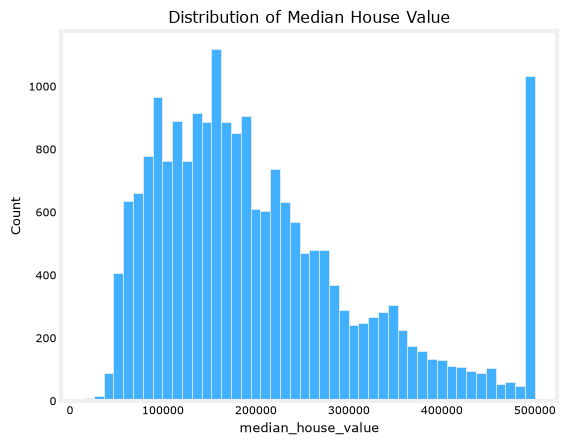

In [132]:
sns.histplot(x = "median_house_value", data = housing_df)
plt.title("Distribution of Median House Value")

<Axes: ylabel='median_house_value'>

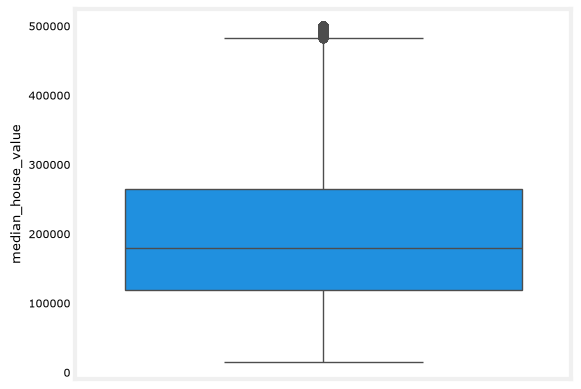

In [133]:
sns.boxplot(y="median_house_value", data = housing_df) #understanding my distribution

<Axes: xlabel='median_income', ylabel='median_house_value'>

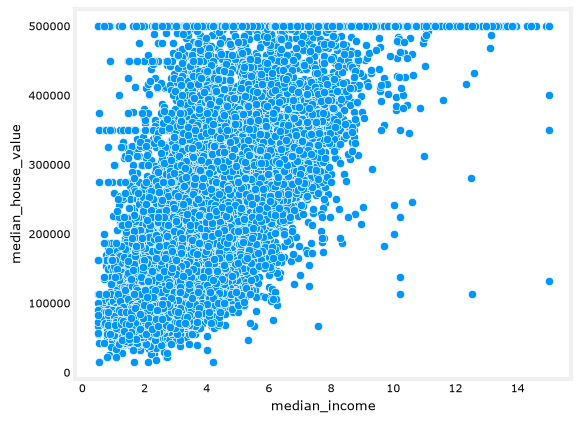

In [134]:
# Understading the relationship between my input feature - median income and target - median house value
sns.scatterplot(x = "median_income", y = "median_house_value", data = housing_df)

In [135]:
housing_df[['median_income', 'median_house_value']].select_dtypes(include=[np.number]).corr('pearson') #close to a positive correlation of 0.69

,median_income,median_house_value
median_income,1.00,0.69
median_house_value,0.69,1.00


> Based on the median income feature the correlation is close to 1 which means there is a positive correlation to the target feature

In [136]:
new_housing_df = housing_df[housing_df['median_house_value'] < 500000] #checking how many values are above 500,000

In [137]:
new_housing_df.reset_index(drop=True, inplace=True)

<Axes: xlabel='median_income', ylabel='median_house_value'>

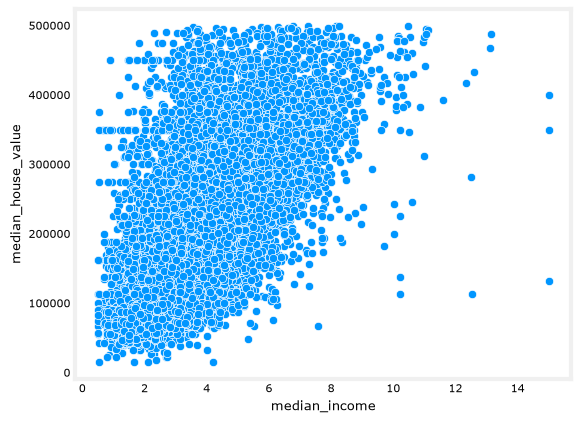

In [138]:
sns.scatterplot(x = "median_income", y = "median_house_value", data = new_housing_df) #removing outliers and checking the relationship again

In [139]:
pearson_correlation = pearsonr(x = new_housing_df['median_income'], y = new_housing_df['median_house_value'])

In [140]:
pearson_correlation

PearsonRResult(statistic=np.float64(0.6467194263256403), pvalue=np.float64(0.0))

> Since the p_value is less than 0.0.5 that means the value obtained from the correlation function is less likely to happen by random chance

### Implementing Linear Regression


> Using Standardisation to normalise the input and output features to reduce the magnitude of the feature during calculation

In [141]:
x_feature = new_housing_df[['median_income']]
y_feature = new_housing_df[['median_house_value']]

In [142]:
stand = StandardScaler()
x_stand = stand.fit_transform(x_feature)
x_stand

array([[ 2.95995239],
       [ 2.94479858],
       [ 2.28006846],
       ...,
       [-1.25840968],
       [-1.15195099],
       [-0.81996796]], shape=(19648, 1))

In [143]:
y_stand  = stand.fit_transform(y_feature)
y_stand

array([[ 2.68302964],
       [ 1.71400929],
       [ 1.64810354],
       ...,
       [-1.02725764],
       [-1.1055207 ],
       [-1.05712117]], shape=(19648, 1))

In [144]:
x_train, x_test , y_train , y_test = train_test_split(x_stand,y_stand,test_size = 0.2, random_state = 42)

x_val , x_temp , y_val , y_temp = train_test_split(x_stand,y_stand , test_size = 0.4, random_state = 42)

In [145]:
print(f"The number of training examples for x feature : {x_train.shape[0]}")
print(f"The number of training examples for y feature : {y_train.shape[0]}")
print(f"The number of training examples for validation : {x_val.shape[0]}")

The number of training examples for x feature : 15718
The number of training examples for y feature : 15718
The number of training examples for validation : 11788


In [146]:
model = LinearRegression()

In [147]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.65]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[125.53]


In [153]:
y_pred = model.predict(x_test) # prediction_value

In [154]:
w , b = model.coef_[0] , model.intercept_[0]
print(w,b)

[0.64603527] -0.0009245686232500728


> R-square is obtained from the calculation of RSS (Residual Sum of squares) & TSS (Total Sum of Squares)


In [ ]:
r_sq = model.score(x_train,y_train) #getting the r_score value
r_sq 

0.420164436486857

> R-square value is low or accuary is low

> Now doing the inverse of the y_prediction to see actual predicted median household values

> Using <font color = "yellow">scaler.inverse_transform</font>

In [162]:
y_pred_inverse = stand.inverse_transform(y_pred)
y_pred_inverse

array([[246261.78056569],
       [235265.0388916 ],
       [238280.85435253],
       ...,
       [109415.65887572],
       [122249.85102931],
       [251182.95228471]], shape=(3930, 1))

In [164]:
y_test_inverse = stand.inverse_transform(y_test)
y_test_inverse

array([[329800.],
       [294700.],
       [195700.],
       ...,
       [ 87500.],
       [138100.],
       [439200.]], shape=(3930, 1))

In [156]:
error = y_pred - y_test
error

array([[-0.86025754],
       [-0.61204768],
       [ 0.43848793],
       ...,
       [ 0.22568246],
       [-0.16322122],
       [-1.9361567 ]], shape=(3930, 1))

In [ ]:
MSE = (np.sum(error)**2)/y_test.shape[0] ## Cost function
MSE

np.float64(0.08396967074372169)

In [166]:
print(y_pred_inverse[0],y_pred[0])
print(y_test_inverse[0],y_test[0])

[246261.78056569] [0.55820569]
[329800.] [1.41846323]


### Implementing Gradient Descent

In [1]:
print(w)
print(b)

NameError: name 'w' is not defined